# 05 — Downstream evidence integration for the Top-100 SAE candidate panel

**Sets**
- **A** — GO over-representation (BP + MF + CC)
- **B** — KEGG pathway over-representation
- **C** — STRING PPI hub genes (cytoHubba-style, strict top-20 intersection of 5 metrics)
- **D** — Sample-level weighted correlation network module evidence

**Primary output:** A ∩ B ∩ C ∩ D, with A ∩ B as the pre-specified fallback.
A graded evidence table (0–4) is exported alongside as supplementary material.

**Corrections applied in this version**
1. **Deterministic top-N ranking.** Ranking with `method="min"` was degenerate:
   eccentricity centrality takes only 2–3 distinct values in a small graph, so an entire
   tie block passed the "top-20" filter and the metric contributed nothing. Each metric now
   returns *exactly* N genes using a documented tie-break chain.
2. **Joint FDR across the three GO libraries** instead of three separate corrections.
3. **Term-cap sensitivity.** Set A/B size is driven by how many enriched terms are kept, so
   the intersection is recomputed at caps of 10, 25 and "all significant".
4. **STRING physical network reported alongside the functional network.** The functional
   network includes text-mining and co-expression channels, which is the main source of
   literature/annotation bias in hub detection.
5. **Correct global sorting in the enrichment bar plots** (previously only the first library
   was shown).
6. **Correlation network named accurately.** This is a WGCNA-*style* Python implementation,
   not the WGCNA R package: soft-thresholding, TOM, hierarchical clustering, adaptive tree
   cut, eigengene-based module merging, and module–trait correlation. Module merging is new
   and substantially reduces the unassigned ("grey") fraction.
7. **Inert-filter reporting.** The |kME| threshold previously excluded zero genes; the number
   removed by each filter is now printed so no filter can look stricter than it is.
8. **Direction and artifact annotation** carried into every output table, because a target
   list without direction cannot be used for prioritisation.

In [37]:
# ============================================================
# 0. Imports + configuration
# ============================================================
from pathlib import Path
import os, re, json, math, warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
import gseapy as gp
import networkx as nx
import requests

from scipy.stats import hypergeom, pearsonr, linregress
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

RNG_SEED = 0
np.random.seed(RNG_SEED)

# ---------------- Paths ----------------
ROOT      = Path(".")
SAE_OUT   = ROOT / "optionB_outputs"
OUT_DIR   = ROOT / "downstream_evidence_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DISC_PATH = ROOT / "gse132465_preprocessing_outputs_before_Xm" / "GSE132465_DL_ready_HVG3000_celllevel.h5ad"

CANDIDATE_FILE  = SAE_OUT / "DOWNSTREAM_panel100.csv"
BACKGROUND_FILE = SAE_OUT / "background_genes.txt"
REPRODUCIBLE_FILE = SAE_OUT / "DOWNSTREAM_panel42.csv"   # optional, for annotation only

# ---------------- Gene-symbol harmonisation ----------------
HGNC_FIX = {"SEPP1":"SELENOP", "C12orf75":"OCC1", "SEPW1":"SELENOW",
            "CTGF":"CCN2", "CYR61":"CCN1", "KIAA0101":"PCLAF",
            "FAM64A":"PIMREG", "GPR56":"ADGRG1", "TMEM66":"SARAF"}
REV_HGNC_FIX = {v: k for k, v in HGNC_FIX.items()}

# Chemokines and immediate-early genes induced by enzymatic tissue dissociation
# (van den Brink 2017; O'Flanagan 2019). Not excluded — annotated, so that any
# selected gene from this family can be reported transparently.
DISSOCIATION_ASSOCIATED = {
    "CXCL1","CXCL2","CXCL3","CXCL8","CCL2","CCL20","IL6","IL1B",
    "FOS","FOSB","JUN","JUNB","EGR1","ATF3","DUSP1","IER2","IER3",
    "NR4A1","NR4A2","ZFP36","SOCS3","GADD45B","KLF4","PPP1R15A",
}
# Canonical reference/housekeeping genes. High STRING degree reflects literature
# co-annotation, not disease biology, so hub membership alone is not evidence here.
HOUSEKEEPING = {"GAPDH","ACTB","TUBB","B2M","PPIA","HPRT1","TBP","RPLP0",
                "SDHA","YWHAZ","UBC","PGK1","EEF1A1","LDHA","ENO1"}

# ---------------- Enrichment ----------------
ORA_FDR          = 0.05
ORA_MIN_OVERLAP  = 2
TERM_CAP         = 25                 # primary cap per library
TERM_CAP_GRID    = [10, 25, None]     # None = all significant (sensitivity)
GO_LIBRARY_PREFIXES = ["GO_Biological_Process", "GO_Molecular_Function", "GO_Cellular_Component"]
KEGG_LIBRARY_PREFIX = "KEGG"

# ---------------- STRING ----------------
STRING_SPECIES        = 9606
STRING_REQUIRED_SCORE = 400          # 0.4 confidence
STRING_TOP_PER_METRIC = 20
STRING_NETWORK_TYPE   = "functional" # primary; "physical" also computed as sensitivity
STRING_CALLER_ID      = "CRC_SAE_downstream_notebook"

# ---------------- Correlation network (WGCNA-style) ----------------
KEEP_TYPES              = ["T cells","Epithelial cells","B cells","Myeloids","Stromal cells"]
WGCNA_MAX_GENES         = 500
WGCNA_MIN_SAMPLES       = 15
WGCNA_MIN_CELLS_PER_TYPE= 20
WGCNA_SOFT_POWERS       = list(range(1, 13))
WGCNA_SCALE_FREE_TARGET = 0.80
WGCNA_MIN_MODULE_SIZE   = 10
WGCNA_MERGE_CORR        = 0.75       # merge modules with |cor(ME_i, ME_j)| >= this
WGCNA_TRAIT_FDR         = 0.05
WGCNA_MIN_ABS_R         = 0.30
WGCNA_MIN_ABS_KME       = 0.50
WGCNA_MAX_MODULE_FRAC   = 0.35   # no single module may exceed 35% of the network

CONFIG = {k: v for k, v in dict(
    ORA_FDR=ORA_FDR, ORA_MIN_OVERLAP=ORA_MIN_OVERLAP, TERM_CAP=TERM_CAP,
    STRING_SPECIES=STRING_SPECIES, STRING_REQUIRED_SCORE=STRING_REQUIRED_SCORE,
    STRING_TOP_PER_METRIC=STRING_TOP_PER_METRIC, STRING_NETWORK_TYPE=STRING_NETWORK_TYPE,
    WGCNA_MAX_GENES=WGCNA_MAX_GENES, WGCNA_MIN_MODULE_SIZE=WGCNA_MIN_MODULE_SIZE,
    WGCNA_MERGE_CORR=WGCNA_MERGE_CORR, WGCNA_TRAIT_FDR=WGCNA_TRAIT_FDR,
    WGCNA_MIN_ABS_R=WGCNA_MIN_ABS_R, WGCNA_MIN_ABS_KME=WGCNA_MIN_ABS_KME).items()}
(OUT_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2))
print(json.dumps(CONFIG, indent=2))

{
  "ORA_FDR": 0.05,
  "ORA_MIN_OVERLAP": 2,
  "TERM_CAP": 25,
  "STRING_SPECIES": 9606,
  "STRING_REQUIRED_SCORE": 400,
  "STRING_TOP_PER_METRIC": 20,
  "STRING_NETWORK_TYPE": "functional",
  "WGCNA_MAX_GENES": 500,
  "WGCNA_MIN_MODULE_SIZE": 10,
  "WGCNA_MERGE_CORR": 0.75,
  "WGCNA_TRAIT_FDR": 0.05,
  "WGCNA_MIN_ABS_R": 0.3,
  "WGCNA_MIN_ABS_KME": 0.5
}


In [38]:
# ============================================================
# 1. Load the Top-100 candidate panel, background, and annotation
# ============================================================
def harmonise_symbol(g):
    return HGNC_FIX.get(str(g).strip(), str(g).strip())

def is_external_mappable(g):
    """Clone-based identifiers (AL928768.3) cannot be queried in GO/KEGG/STRING."""
    g = str(g).strip()
    return bool(g) and g.lower() != "nan" and "." not in g and not re.match(r"^LINC\d{5}$", g)

if not CANDIDATE_FILE.exists():
    raise FileNotFoundError(f"{CANDIDATE_FILE} missing — run notebook 04's export cell first.")

cand_df = pd.read_csv(CANDIDATE_FILE)
gene_col = "gene_hgnc" if "gene_hgnc" in cand_df.columns else "gene"
cand_df["gene_std"] = cand_df[gene_col].map(harmonise_symbol)
cand_df = cand_df.drop_duplicates("gene_std").reset_index(drop=True)

candidate_genes_all      = cand_df["gene_std"].tolist()
candidate_genes_external = [g for g in candidate_genes_all if is_external_mappable(g)]
external_unmappable      = [g for g in candidate_genes_all if not is_external_mappable(g)]

# ---- background: the SAE shared feature space, NOT the whole genome ----
if BACKGROUND_FILE.exists():
    background_all = [harmonise_symbol(g) for g in BACKGROUND_FILE.read_text().split()]
else:
    if not DISC_PATH.exists():
        raise FileNotFoundError(f"Neither {BACKGROUND_FILE} nor {DISC_PATH} found.")
    _t = sc.read_h5ad(DISC_PATH, backed="r")
    background_all = [harmonise_symbol(g) for g in _t.var_names.tolist()]
    del _t

background_all      = list(dict.fromkeys(background_all))
background_external = [g for g in background_all if is_external_mappable(g)]
missing_bg = sorted(set(candidate_genes_external) - set(background_external))
if missing_bg:
    print("WARNING — candidates absent from background, adding them:", missing_bg)
    background_external += missing_bg
background_external = list(dict.fromkeys(background_external))

# ---- annotation carried through every downstream table ----
ann_cols = [c for c in ["rank","selection_freq","mean_abs_attr","lfc_adjusted",
                        "lfc_epithelial","direction","attr_specificity"] if c in cand_df.columns]
ANN = cand_df.set_index("gene_std")[ann_cols].copy()
ANN["dissociation_associated"] = ANN.index.isin(DISSOCIATION_ASSOCIATED)
ANN["housekeeping"] = ANN.index.isin(HOUSEKEEPING)

if REPRODUCIBLE_FILE.exists():
    rep = pd.read_csv(REPRODUCIBLE_FILE)
    rcol = "gene_hgnc" if "gene_hgnc" in rep.columns else "gene"
    repro = {harmonise_symbol(g) for g in rep[rcol]}
else:
    repro = set()
ANN["cross_cohort_reproducible"] = ANN.index.isin(repro)

print(f"Candidates          : {len(candidate_genes_all)}")
print(f"  externally mappable: {len(candidate_genes_external)}")
print(f"  unmappable         : {external_unmappable or 'none'}")
print(f"Background (external): {len(background_external)}")
print(f"Cross-cohort reproducible among candidates: {int(ANN['cross_cohort_reproducible'].sum())}")
print(f"Dissociation-associated among candidates  : "
      f"{sorted(ANN.index[ANN['dissociation_associated']])}")

Candidates          : 100
  externally mappable: 99
  unmappable         : ['AL928768.3']
Background (external): 2632
Cross-cohort reproducible among candidates: 42
Dissociation-associated among candidates  : ['CCL2', 'CCL20', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8']


In [39]:
# ============================================================
# 2A. Over-representation analysis helpers
# ============================================================
def _year_key(name):
    m = re.findall(r"(20\d{2})", name)
    return int(m[-1]) if m else -1

def resolve_enrichr_library(prefix, organism="Human"):
    names = gp.get_library_name(organism=organism)
    matches = [x for x in names if x.startswith(prefix)]
    if not matches:
        tok = prefix.lower().replace("_", " ").split()[0]
        matches = [x for x in names if tok in x.lower()]
    if not matches:
        raise ValueError(f"No Enrichr library matched prefix: {prefix}")
    return sorted(matches, key=lambda x: (_year_key(x), x), reverse=True)[0]

def get_library_cached(libname, organism="Human"):
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", libname)
    cache = OUT_DIR / f"library_{safe}.json"
    if cache.exists():
        return {k: set(v) for k, v in json.loads(cache.read_text()).items()}
    lib = {str(k): set(map(str, v)) for k, v in gp.get_library(name=libname, organism=organism).items()}
    cache.write_text(json.dumps({k: sorted(v) for k, v in lib.items()}))
    return lib

def ora_raw(query_genes, background, gene_sets, library_name, min_overlap=2):
    """Hypergeometric ORA. Returns RAW p-values; FDR is applied jointly afterwards."""
    bg    = set(background)
    query = set(query_genes) & bg
    N, n  = len(bg), len(query)
    if n == 0:
        return pd.DataFrame()
    rows = []
    for term, members in gene_sets.items():
        members_bg = set(members) & bg
        K = len(members_bg)
        overlap = query & members_bg
        k = len(overlap)
        if k < min_overlap or K == 0:
            continue
        rows.append({"Library": library_name, "Term": term,
                     "Overlap_k": k, "Query_n": n, "TermBackground_K": K, "Background_N": N,
                     "P_value": hypergeom.sf(k - 1, N, K, n),
                     "Enrichment": (k / n) / (K / N),
                     "Genes": ";".join(sorted(overlap))})
    return pd.DataFrame(rows)

def add_joint_fdr(df):
    """Benjamini–Hochberg across ALL terms tested, not per library."""
    if df is None or df.empty:
        return pd.DataFrame(columns=["Library","Term","Overlap_k","Query_n","TermBackground_K",
                                     "Background_N","P_value","FDR","Enrichment","Genes"])
    df = df.copy()
    df["FDR"] = multipletests(df["P_value"].values, method="fdr_bh")[1]
    return df.sort_values(["FDR","P_value","Enrichment"],
                          ascending=[True,True,False]).reset_index(drop=True)

def genes_from_terms(sig_df):
    if sig_df is None or sig_df.empty:
        return set()
    out = set()
    for s in sig_df["Genes"].dropna():
        out.update(g for g in str(s).split(";") if g)
    return out

def cap_terms(sig_df, cap, per_library=True):
    """Keep the top `cap` terms (by FDR). cap=None keeps all significant terms."""
    if sig_df is None or sig_df.empty or cap is None:
        return sig_df
    s = sig_df.sort_values(["FDR","P_value"])
    return (s.groupby("Library", group_keys=False).head(cap) if per_library else s.head(cap)
            ).reset_index(drop=True)

In [40]:
# ============================================================
# 2B. Set A — GO evidence (joint FDR across BP/MF/CC)
# ============================================================
go_raw, resolved_go = [], []
for prefix in GO_LIBRARY_PREFIXES:
    libname = resolve_enrichr_library(prefix)
    resolved_go.append(libname)
    print("GO library:", libname)
    go_raw.append(ora_raw(candidate_genes_external, background_external,
                          get_library_cached(libname), libname, ORA_MIN_OVERLAP))

go_all = add_joint_fdr(pd.concat([d for d in go_raw if not d.empty], ignore_index=True)
                       if any(not d.empty for d in go_raw) else pd.DataFrame())
go_sig = go_all[go_all["FDR"] <= ORA_FDR].copy()
go_top = cap_terms(go_sig, TERM_CAP, per_library=True)
A_GO   = genes_from_terms(go_top)

go_all.to_csv(OUT_DIR / "GO_enrichment_full.csv", index=False)
go_sig.to_csv(OUT_DIR / "GO_enrichment_significant.csv", index=False)
go_top.to_csv(OUT_DIR / "GO_enrichment_terms_used_for_SetA.csv", index=False)
(OUT_DIR / "setA_GO_genes.txt").write_text("\n".join(sorted(A_GO)))

print(f"\nTerms tested: {len(go_all)} | significant (FDR<={ORA_FDR}): {len(go_sig)} "
      f"| used for Set A: {len(go_top)}")
print(f"Set A (GO) = {len(A_GO)} genes")
print(sorted(A_GO))
if not go_sig.empty:
    display(go_top[["Library","Term","Overlap_k","FDR","Enrichment","Genes"]].head(20))
else:
    print("WARNING: no GO term passed FDR.")

GO library: GO_Biological_Process_2026
GO library: GO_Molecular_Function_2026
GO library: GO_Cellular_Component_2026

Terms tested: 461 | significant (FDR<=0.05): 76 | used for Set A: 60
Set A (GO) = 66 genes
['A2M', 'ADAMDEC1', 'AGR2', 'B2M', 'BGN', 'CA4', 'CCL2', 'CCL20', 'CCL5', 'CD24', 'CD36', 'CFD', 'CLDN3', 'CLDN4', 'CLDN5', 'COL1A1', 'CTSB', 'CTSL', 'CXCL1', 'CXCL13', 'CXCL14', 'CXCL2', 'CXCL3', 'CXCL8', 'CXCR4', 'DCN', 'DUSP2', 'DUSP4', 'DUSP5', 'EPCAM', 'FBLN1', 'FN1', 'FYN', 'GAPDH', 'GDF15', 'GNLY', 'GSN', 'GUCA2A', 'GUCA2B', 'GZMA', 'HLA-B', 'HLA-DPB1', 'HLA-DQB1', 'HLA-DRA', 'HLA-DRB5', 'IFI27', 'IFITM1', 'ITM2C', 'KRT18', 'LCN2', 'MZB1', 'NKG7', 'PIGR', 'PSMB9', 'RAC2', 'REG1A', 'RGS1', 'RGS2', 'S100A11', 'S100P', 'SELENOP', 'SERPINH1', 'SPARC', 'SPARCL1', 'SPP1', 'ZG16']


,Library,Term,Overlap_k,FDR,Enrichment,Genes
0,GO_Biological_Process_2026,Antimicrobial Humoral Immune Response Mediated...,13,0.000297,5.158450,B2M;CCL2;CCL20;CCL5;CXCL1;CXCL13;CXCL14;CXCL2;...
1,GO_Cellular_Component_2026,Transport Vesicle Membrane (GO:0030658),7,0.000660,9.794790,B2M;CA4;HLA-B;HLA-DPB1;HLA-DQB1;HLA-DRA;HLA-DRB5
2,GO_Biological_Process_2026,Antimicrobial Humoral Response (GO:0019730),13,0.000660,4.320202,B2M;CCL2;CCL20;CCL5;CXCL1;CXCL13;CXCL14;CXCL2;...
3,GO_Cellular_Component_2026,MHC Protein Complex (GO:0042611),6,0.000660,11.393939,B2M;HLA-B;HLA-DPB1;HLA-DQB1;HLA-DRA;HLA-DRB5
4,GO_Biological_Process_2026,Antigen Processing and Presentation of Exogeno...,7,0.000715,8.459137,B2M;CTSL;HLA-B;HLA-DPB1;HLA-DQB1;HLA-DRA;HLA-DRB5
5,GO_Cellular_Component_2026,Lysosome (GO:0005764),14,0.000715,3.837134,B2M;BGN;CTSB;CTSL;CXCR4;DCN;GNLY;HLA-DPB1;HLA-...
6,GO_Molecular_Function_2026,Chemokine Activity (GO:0008009),9,0.000715,5.981818,CCL2;CCL20;CCL5;CXCL1;CXCL13;CXCL14;CXCL2;CXCL...
7,GO_Cellular_Component_2026,Coated Vesicle Membrane (GO:0030662),6,0.000736,9.969697,B2M;HLA-B;HLA-DPB1;HLA-DQB1;HLA-DRA;HLA-DRB5
8,GO_Cellular_Component_2026,ER to Golgi Transport Vesicle Membrane (GO:001...,6,0.000736,9.969697,B2M;HLA-B;HLA-DPB1;HLA-DQB1;HLA-DRA;HLA-DRB5
9,GO_Molecular_Function_2026,Chemokine Receptor Binding (GO:0042379),9,0.000767,5.696970,CCL2;CCL20;CCL5;CXCL1;CXCL13;CXCL14;CXCL2;CXCL...


In [41]:
# ============================================================
# 2C. Set B — KEGG evidence
# ============================================================
kegg_libname = resolve_enrichr_library(KEGG_LIBRARY_PREFIX)
print("KEGG library:", kegg_libname)

kegg_all = add_joint_fdr(ora_raw(candidate_genes_external, background_external,
                                 get_library_cached(kegg_libname), kegg_libname, ORA_MIN_OVERLAP))
kegg_sig = kegg_all[kegg_all["FDR"] <= ORA_FDR].copy()
kegg_top = cap_terms(kegg_sig, TERM_CAP, per_library=False)
B_KEGG   = genes_from_terms(kegg_top)

kegg_all.to_csv(OUT_DIR / "KEGG_enrichment_full.csv", index=False)
kegg_sig.to_csv(OUT_DIR / "KEGG_enrichment_significant.csv", index=False)
kegg_top.to_csv(OUT_DIR / "KEGG_enrichment_terms_used_for_SetB.csv", index=False)
(OUT_DIR / "setB_KEGG_genes.txt").write_text("\n".join(sorted(B_KEGG)))

print(f"\nPathways tested: {len(kegg_all)} | significant: {len(kegg_sig)} | used: {len(kegg_top)}")
print(f"Set B (KEGG) = {len(B_KEGG)} genes")
print(sorted(B_KEGG))
if not kegg_sig.empty:
    display(kegg_top[["Term","Overlap_k","FDR","Enrichment","Genes"]].head(20))
else:
    print("WARNING: no KEGG pathway passed FDR.")

KEGG library: KEGG_2026

Pathways tested: 97 | significant: 28 | used: 25
Set B (KEGG) = 42 genes
['B2M', 'CCL2', 'CCL20', 'CCL3L3', 'CCL5', 'CD24', 'CD36', 'CLDN3', 'CLDN4', 'CLDN5', 'COL1A1', 'CTSB', 'CTSL', 'CXCL1', 'CXCL13', 'CXCL14', 'CXCL2', 'CXCL3', 'CXCL8', 'CXCR4', 'DUSP2', 'DUSP4', 'DUSP5', 'EPCAM', 'FCER1G', 'FN1', 'FYN', 'GAPDH', 'GDF15', 'GNG11', 'HCST', 'HLA-B', 'HLA-DRA', 'HLA-DRB5', 'KRT18', 'KRT19', 'KRT8', 'LCN2', 'RAC2', 'S100A11', 'S100A6', 'SELENOP']


,Term,Overlap_k,FDR,Enrichment,Genes
0,CHEMOKINE SIGNALING PATHWAY,13,0.000007,6.171717,CCL2;CCL20;CCL3L3;CCL5;CXCL1;CXCL13;CXCL14;CXC...
1,RHEUMATOID ARTHRITIS,11,0.000121,5.517820,CCL2;CCL20;CCL3L3;CCL5;CTSL;CXCL1;CXCL2;CXCL3;...
2,VIRAL PROTEIN INTERACTION WITH CYTOKINE AND CY...,11,0.000167,5.130604,CCL2;CCL20;CCL3L3;CCL5;CXCL1;CXCL13;CXCL14;CXC...
3,HUMAN CYTOMEGALOVIRUS INFECTION,9,0.000167,6.296651,B2M;CCL2;CCL3L3;CCL5;CXCL8;CXCR4;GNG11;HLA-B;RAC2
4,LIPID AND ATHEROSCLEROSIS,9,0.000262,5.835920,CCL2;CCL3L3;CCL5;CD36;CXCL1;CXCL2;CXCL3;CXCL8;...
5,EPITHELIAL CELL SIGNALING IN HELICOBACTER PYLO...,5,0.001115,10.225330,CCL5;CXCL1;CXCL2;CXCL3;CXCL8
6,IL-17 SIGNALING PATHWAY,7,0.004539,5.029757,CCL2;CCL20;CXCL1;CXCL2;CXCL3;CXCL8;LCN2
7,NOD-LIKE RECEPTOR SIGNALING PATHWAY,7,0.004539,4.897395,CCL2;CCL5;CTSB;CXCL1;CXCL2;CXCL3;CXCL8
8,KAPOSI SARCOMA-ASSOCIATED HERPESVIRUS INFECTION,6,0.004539,5.696970,CXCL1;CXCL2;CXCL3;CXCL8;GNG11;HLA-B
9,ANTIGEN PROCESSING AND PRESENTATION,6,0.004539,5.696970,B2M;CTSB;CTSL;HLA-B;HLA-DRA;HLA-DRB5


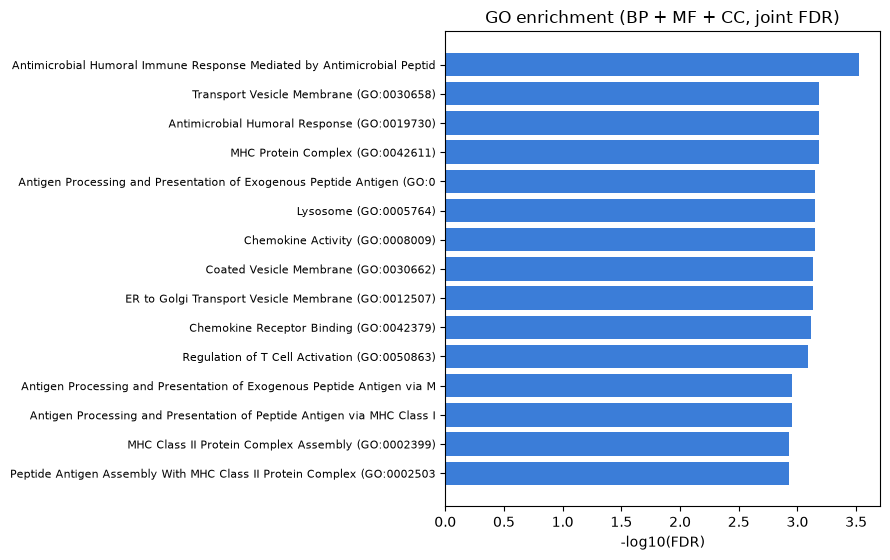

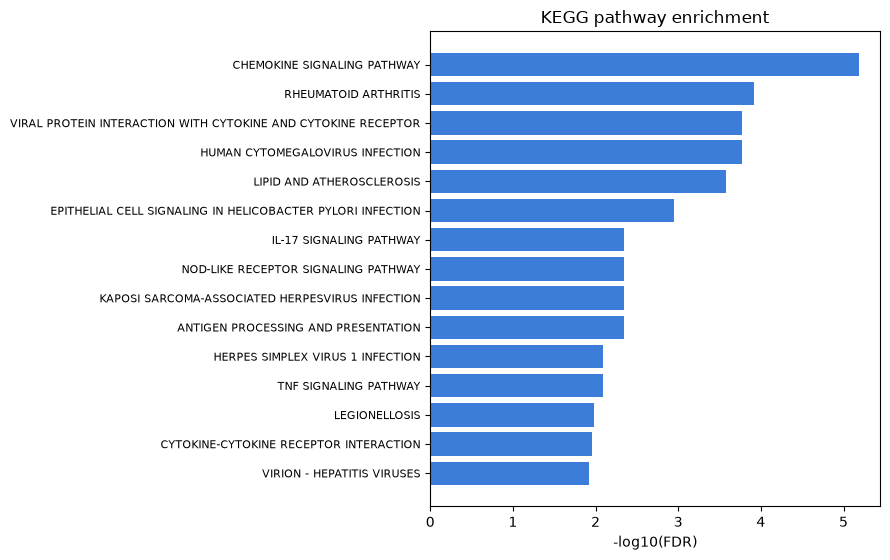


Significant GO terms per sub-ontology:
Library
GO_Biological_Process_2026    41
GO_Cellular_Component_2026    25
GO_Molecular_Function_2026    10


In [42]:
# ============================================================
# 2D. Enrichment bar plots
# ============================================================
def plot_enrichment(df, title, out_file, n=15):
    """Sorts globally by FDR first — the previous version showed only the first library."""
    if df is None or df.empty:
        print(f"{title}: nothing to plot"); return
    d = df.sort_values("FDR").head(n).iloc[::-1]
    score = -np.log10(np.maximum(d["FDR"].astype(float).values, 1e-300))
    fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * len(d))))
    ax.barh(range(len(d)), score, color="#3b7dd8")
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([t[:70] for t in d["Term"]], fontsize=8)
    ax.set_xlabel("-log10(FDR)"); ax.set_title(title)
    plt.tight_layout(); plt.savefig(out_file, dpi=250, bbox_inches="tight"); plt.show()

plot_enrichment(go_sig,   "GO enrichment (BP + MF + CC, joint FDR)", OUT_DIR / "GO_enrichment.png")
plot_enrichment(kegg_sig, "KEGG pathway enrichment",                 OUT_DIR / "KEGG_enrichment.png")

if not go_sig.empty:
    print("\nSignificant GO terms per sub-ontology:")
    print(go_sig["Library"].value_counts().to_string())

In [43]:
# ============================================================
# 3A. Query STRING — both network types
# ============================================================
STRING_BASE = "https://string-db.org/api"

def string_post(method, params, timeout=180):
    r = requests.post(f"{STRING_BASE}/json/{method}", data=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

mapping = pd.DataFrame(string_post("get_string_ids", {
    "identifiers": "\r".join(candidate_genes_external),
    "species": STRING_SPECIES, "limit": 1, "echo_query": 1,
    "caller_identity": STRING_CALLER_ID}))
if mapping.empty:
    raise RuntimeError("STRING mapping returned nothing — check internet access.")
mapping.to_csv(OUT_DIR / "STRING_mapping.csv", index=False)

query_to_pref, pref_to_query = {}, {}
for _, r in mapping.iterrows():
    q, p = str(r.get("queryItem","")), str(r.get("preferredName",""))
    if q and p and q not in query_to_pref:
        query_to_pref[q] = p
        pref_to_query.setdefault(p, q)

string_query_names = [query_to_pref[g] for g in candidate_genes_external if g in query_to_pref]
unmapped = sorted(set(candidate_genes_external) - set(query_to_pref))
print(f"STRING mapped: {len(string_query_names)}/{len(candidate_genes_external)}")
if unmapped:
    print("Unmapped:", unmapped)

def fetch_edges(network_type):
    js = string_post("network", {
        "identifiers": "\r".join(string_query_names), "species": STRING_SPECIES,
        "required_score": STRING_REQUIRED_SCORE, "add_nodes": 0,
        "network_type": network_type, "caller_identity": STRING_CALLER_ID})
    e = pd.DataFrame(js)
    e.to_csv(OUT_DIR / f"STRING_edges_{network_type}.csv", index=False)
    print(f"  {network_type:10s}: {len(e)} interactions")
    return e

print("STRING interactions:")
edges_by_type = {t: fetch_edges(t) for t in ["functional", "physical"]}

STRING mapped: 99/99
STRING interactions:
  functional: 430 interactions
  physical  : 93 interactions


In [44]:
# ============================================================
# 3B. cytoHubba-style centrality + Set C
# ============================================================
def build_graph(edges, nodes):
    G = nx.Graph(); G.add_nodes_from(nodes)
    for _, r in edges.iterrows():
        a, b = str(r.get("preferredName_A","")), str(r.get("preferredName_B",""))
        if a and b and a != b:
            G.add_edge(a, b, weight=float(r.get("score", 0.0)))
    return G

def mnc_score(G, n):
    nb = list(G.neighbors(n))
    return max((len(c) for c in nx.connected_components(G.subgraph(nb))), default=0) if nb else 0

def mcc_scores(G):
    s = {n: 0 for n in G.nodes()}
    for cl in nx.find_cliques(G):
        if len(cl) >= 2:
            c = math.factorial(len(cl) - 1)
            for n in cl:
                s[n] += c
    return s

def inverse_eccentricity(G):
    out = {n: 0.0 for n in G.nodes()}
    for comp in nx.connected_components(G):
        if len(comp) <= 1:
            continue
        for n, e in nx.eccentricity(G.subgraph(comp)).items():
            out[n] = 1.0 / e if e else 0.0
    return out

def bottleneck_scores(G):
    """cytoHubba Bottleneck (Lin 2008): for each source's shortest-path tree, a node is a
    bottleneck when its descendant count >= |V|/4; BN = number of such trees."""
    s = {n: 0 for n in G.nodes()}
    for comp in nx.connected_components(G):
        nodes = sorted(comp); sub = G.subgraph(nodes); thr = len(nodes) / 4.0
        for src in nodes:
            tree = nx.bfs_tree(sub, source=src, sort_neighbors=sorted)
            desc = {n: 0 for n in tree.nodes()}
            for n in reversed(list(nx.topological_sort(tree))):
                desc[n] = sum(1 + desc[c] for c in tree.successors(n))
            for n, w in desc.items():
                if w >= thr:
                    s[n] += 1
    return s

METRICS = ["Degree","MNC","MCC","EccentricityCentrality","Bottleneck"]

def centrality_table(G):
    deg = dict(G.degree())
    df = pd.DataFrame({
        "string_gene": sorted(G.nodes()),
        "Degree": [deg[n] for n in sorted(G.nodes())],
        "MNC":    [mnc_score(G, n) for n in sorted(G.nodes())],
        "MCC":    [mcc_scores(G)[n] for n in sorted(G.nodes())],
        "EccentricityCentrality": [inverse_eccentricity(G)[n] for n in sorted(G.nodes())],
        "Bottleneck": [bottleneck_scores(G)[n] for n in sorted(G.nodes())],
    })
    bt = nx.betweenness_centrality(G, normalized=True)
    df["Betweenness_diagnostic"] = df["string_gene"].map(bt)
    df["gene"] = df["string_gene"].map(pref_to_query).fillna(df["string_gene"])
    return df

def top_n_deterministic(df, metric, n):
    """Return EXACTLY n genes. `rank(method='min')` was degenerate: eccentricity has only
    2-3 distinct values, so a whole tie block passed 'rank <= 20' and the metric filtered
    nothing. Tie-break chain: metric desc -> Degree desc -> MCC desc -> gene name asc."""
    ordered = df.sort_values([metric, "Degree", "MCC", "string_gene"],
                             ascending=[False, False, False, True])
    ordered = ordered[ordered["Degree"] > 0]
    return set(ordered.head(min(n, len(ordered)))["gene"])

def compute_set_c(edges, tag):
    G  = build_graph(edges, string_query_names)
    ct = centrality_table(G)
    connected = int((ct["Degree"] > 0).sum())
    k = min(STRING_TOP_PER_METRIC, connected)

    tops = {m: top_n_deterministic(ct, m, k) for m in METRICS}
    for m in METRICS:
        ct[f"top{k}_{m}"] = ct["gene"].isin(tops[m])
    ct["metric_hits"] = ct[[f"top{k}_{m}" for m in METRICS]].sum(axis=1)
    ct["strict_all5"] = ct["metric_hits"] == len(METRICS)
    ct = ct.sort_values(["metric_hits","Degree","Bottleneck","MCC"],
                        ascending=False).reset_index(drop=True)

    print(f"\n--- STRING [{tag}] ---")
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges "
          f"| connected: {connected} | top-k per metric: {k}")
    print("Distinct values per metric (low count = weak discrimination):")
    print("  " + " | ".join(f"{m}:{ct[m].nunique()}" for m in METRICS))
    strict = set(ct.loc[ct["strict_all5"], "gene"])
    print(f"Strict 5/5 intersection: {len(strict)} -> {sorted(strict)}")
    ct.to_csv(OUT_DIR / f"STRING_centrality_{tag}.csv", index=False)
    return G, ct, strict, k

G_func,  cent_func,  C_func,  K_FUNC = compute_set_c(edges_by_type["functional"], "functional")
G_phys,  cent_phys,  C_phys,  K_PHYS = compute_set_c(edges_by_type["physical"],  "physical")

# Primary Set C follows the pre-specified network type; the other is a sensitivity analysis.
G_PPI, centrality, C_STRING = ((G_func, cent_func, C_func)
                               if STRING_NETWORK_TYPE == "functional"
                               else (G_phys, cent_phys, C_phys))
(OUT_DIR / "setC_STRING_hubs.txt").write_text("\n".join(sorted(C_STRING)))
(OUT_DIR / "setC_STRING_physical_sensitivity.txt").write_text("\n".join(sorted(C_phys)))

print(f"\n>>> Set C (primary, {STRING_NETWORK_TYPE}) = {len(C_STRING)}: {sorted(C_STRING)}")
print(f">>> Physical-network sensitivity      = {len(C_phys)}: {sorted(C_phys)}")
print(f">>> Shared between network types      = {sorted(C_STRING & C_phys)}")
display(centrality.head(25))


--- STRING [functional] ---
Graph: 99 nodes, 430 edges | connected: 94 | top-k per metric: 20
Distinct values per metric (low count = weak discrimination):
  Degree:25 | MNC:26 | MCC:68 | EccentricityCentrality:7 | Bottleneck:11
Strict 5/5 intersection: 11 -> ['B2M', 'CCL2', 'CCL5', 'COL1A1', 'CXCL13', 'CXCL8', 'CXCR4', 'EPCAM', 'FN1', 'GAPDH', 'LCN2']

--- STRING [physical] ---
Graph: 99 nodes, 93 edges | connected: 57 | top-k per metric: 20
Distinct values per metric (low count = weak discrimination):
  Degree:11 | MNC:9 | MCC:18 | EccentricityCentrality:7 | Bottleneck:9
Strict 5/5 intersection: 5 -> ['COL1A1', 'CXCL8', 'CXCR4', 'FN1', 'SPP1']

>>> Set C (primary, functional) = 11: ['B2M', 'CCL2', 'CCL5', 'COL1A1', 'CXCL13', 'CXCL8', 'CXCR4', 'EPCAM', 'FN1', 'GAPDH', 'LCN2']
>>> Physical-network sensitivity      = 5: ['COL1A1', 'CXCL8', 'CXCR4', 'FN1', 'SPP1']
>>> Shared between network types      = ['COL1A1', 'CXCL8', 'CXCR4', 'FN1']


,string_gene,Degree,MNC,MCC,EccentricityCentrality,Bottleneck,Betweenness_diagnostic,gene,top20_Degree,top20_MNC,top20_MCC,top20_EccentricityCentrality,top20_Bottleneck,metric_hits,strict_all5
0,GAPDH,41,41,74222,0.25,25,0.202104,GAPDH,True,True,True,True,True,5,True
1,FN1,34,34,33542,0.20,4,0.091573,FN1,True,True,True,True,True,5,True
2,CCL2,30,30,794578,0.20,18,0.054806,CCL2,True,True,True,True,True,5,True
3,CCL5,28,28,778222,0.20,8,0.072443,CCL5,True,True,True,True,True,5,True
4,CXCL8,28,27,795919,0.20,4,0.047790,CXCL8,True,True,True,True,True,5,True
5,CXCR4,26,26,759922,0.25,8,0.098629,CXCR4,True,True,True,True,True,5,True
6,B2M,23,23,31060,0.25,18,0.066891,B2M,True,True,True,True,True,5,True
7,COL1A1,22,22,9586,0.20,10,0.033451,COL1A1,True,True,True,True,True,5,True
8,LCN2,16,15,35415,0.20,2,0.026330,LCN2,True,True,True,True,True,5,True
9,CXCL13,15,14,725805,0.20,3,0.025117,CXCL13,True,True,True,True,True,5,True


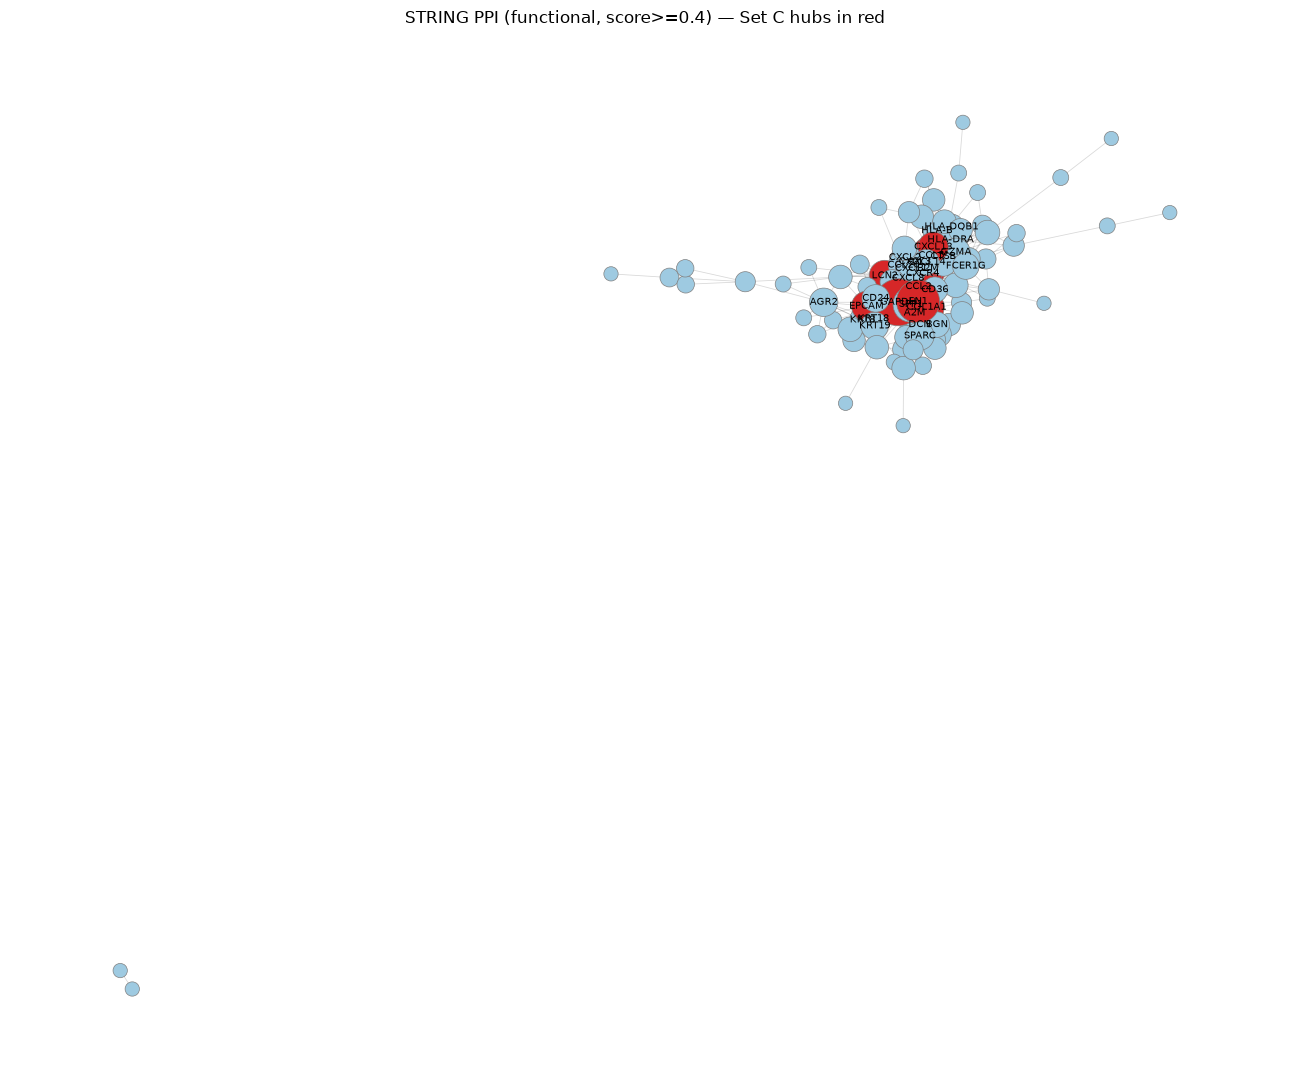

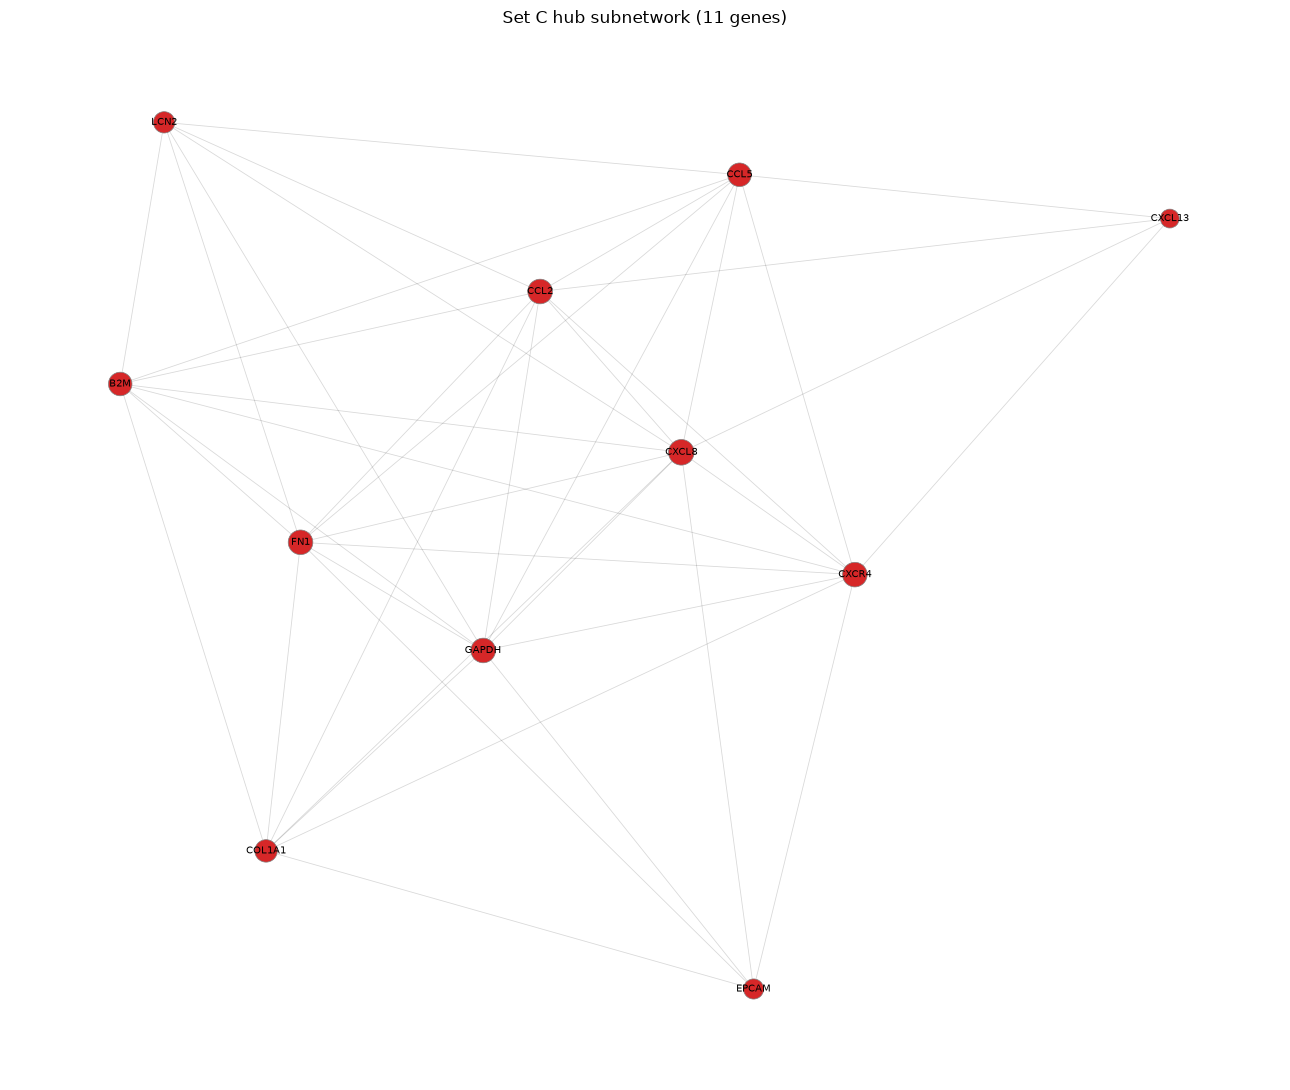

In [45]:
# ============================================================
# 3C. Network figures
# ============================================================
def draw_network(G, hubs, title, out_file, seed=RNG_SEED):
    Gd = G.subgraph([n for n in G.nodes() if G.degree(n) > 0]).copy()
    if Gd.number_of_nodes() == 0:
        print("Empty graph."); return
    pos = nx.spring_layout(Gd, seed=seed, k=1.6/np.sqrt(Gd.number_of_nodes()), iterations=200)
    hub_pref = {query_to_pref.get(g, g) for g in hubs}
    deg = dict(Gd.degree())
    fig, ax = plt.subplots(figsize=(13, 11))
    nx.draw_networkx_edges(Gd, pos, alpha=0.15, width=0.6, ax=ax)
    nx.draw_networkx_nodes(
        Gd, pos, ax=ax,
        node_size=[80 + 26 * deg[n] for n in Gd.nodes()],
        node_color=["#d62728" if n in hub_pref else "#9ecae1" for n in Gd.nodes()],
        edgecolors="grey", linewidths=0.5)
    nx.draw_networkx_labels(
        Gd, pos, ax=ax, font_size=7,
        labels={n: n for n in Gd.nodes() if n in hub_pref or deg[n] >= 10})
    ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.savefig(out_file, dpi=300, bbox_inches="tight"); plt.show()

draw_network(G_PPI, C_STRING,
             f"STRING PPI ({STRING_NETWORK_TYPE}, score>=0.4) — Set C hubs in red",
             OUT_DIR / "PPI_network.png")

if C_STRING:
    sub = G_PPI.subgraph([query_to_pref.get(g, g) for g in C_STRING]).copy()
    draw_network(sub, C_STRING, f"Set C hub subnetwork ({len(C_STRING)} genes)",
                 OUT_DIR / "PPI_hub_subnetwork.png")

In [46]:
# ============================================================
# 4A. Cell-type-balanced sample-level expression
# ============================================================
# Single-cell correlation networks violate independence (cells share a patient), so the
# network is built on SAMPLE-level profiles. Within each sample, cell types are averaged
# with equal weight so that module structure reflects expression, not composition.
if not DISC_PATH.exists():
    raise FileNotFoundError(f"Discovery h5ad not found: {DISC_PATH}")

adata = sc.read_h5ad(DISC_PATH)
class_col, celltype_col = "Class", "Cell_type"
sample_col  = "Sample"  if "Sample"  in adata.obs.columns else None
patient_col = "Patient" if "Patient" in adata.obs.columns else None
adata = adata[adata.obs[celltype_col].astype(str).isin(KEEP_TYPES)].copy()
varset = set(map(str, adata.var_names))

def to_adata_symbol(g):
    if g in varset: return g
    old = REV_HGNC_FIX.get(g)
    return old if old in varset else None

cand_pairs = [(g, a) for g in candidate_genes_all if (a := to_adata_symbol(g))]
cand_map = pd.DataFrame(cand_pairs, columns=["gene","adata_gene"]).drop_duplicates("gene")

score_col, ascending = None, False
for c in ["dispersions_norm","variances_norm","variances"]:
    if c in adata.var.columns: score_col = c; break
if score_col is None and "highly_variable_rank" in adata.var.columns:
    score_col, ascending = "highly_variable_rank", True

bg_pairs = [(g, a) for g in background_all if (a := to_adata_symbol(g))]
bg_map = pd.DataFrame(bg_pairs, columns=["gene","adata_gene"]).drop_duplicates("gene")
if score_col:
    bg_map["s"] = bg_map["adata_gene"].map(adata.var[score_col].astype(float))
    bg_map = bg_map.sort_values("s", ascending=ascending, na_position="last")

extras = bg_map[~bg_map["gene"].isin(cand_map["gene"])]
wgcna_map = pd.concat([cand_map, extras.head(max(0, WGCNA_MAX_GENES - len(cand_map)))],
                      ignore_index=True).drop_duplicates("gene").head(WGCNA_MAX_GENES)
if len(wgcna_map) < 20:
    raise RuntimeError(f"Only {len(wgcna_map)} genes available.")

sub = adata[:, wgcna_map["adata_gene"].tolist()].copy()
ext_genes = wgcna_map["gene"].tolist()

sample_ids = (sub.obs[sample_col].astype(str).values if sample_col
              else (sub.obs[patient_col].astype(str) + "_" + sub.obs[class_col].astype(str)).values)
classes, celltypes = sub.obs[class_col].astype(str).values, sub.obs[celltype_col].astype(str).values
Xsub = sub.X

rows, meta = [], []
for s in pd.unique(sample_ids):
    sm = sample_ids == s
    if sm.sum() == 0: continue
    ct_means = []
    for ct in KEEP_TYPES:
        m = sm & (celltypes == ct)
        if int(m.sum()) >= WGCNA_MIN_CELLS_PER_TYPE:
            ct_means.append(np.asarray(Xsub[m].mean(axis=0)).ravel().astype(float))
    if not ct_means:
        ct_means = [np.asarray(Xsub[sm].mean(axis=0)).ravel().astype(float)]
    rows.append(np.vstack(ct_means).mean(axis=0))
    meta.append({"sample": s,
                 "Patient": (str(sub.obs.loc[sub.obs_names[sm][0], patient_col])
                             if patient_col else str(s).split("_")[0]),
                 "Class": pd.Series(classes[sm]).value_counts().index[0],
                 "n_cells": int(sm.sum()), "n_celltypes_used": len(ct_means)})

expr = pd.DataFrame(np.vstack(rows), index=[m["sample"] for m in meta], columns=ext_genes)
sample_meta = pd.DataFrame(meta).set_index("sample").loc[expr.index]
sample_meta["Tumor"] = (sample_meta["Class"] == "Tumor").astype(int)

expr = expr.loc[:, expr.var(axis=0) > 1e-10]
print("Sample-level matrix:", expr.shape)
print(sample_meta["Class"].value_counts().to_string())
print("Patients:", sample_meta["Patient"].nunique(),
      "| mean cell types per sample:", round(sample_meta["n_celltypes_used"].mean(), 2))
if len(expr) < WGCNA_MIN_SAMPLES:
    raise RuntimeError(f"Only {len(expr)} samples; need >= {WGCNA_MIN_SAMPLES}.")

expr.to_csv(OUT_DIR / "WGCNA_sample_level_expression.csv")
sample_meta.to_csv(OUT_DIR / "WGCNA_sample_metadata.csv")

Sample-level matrix: (33, 500)
Class
Tumor     23
Normal    10
Patients: 23 | mean cell types per sample: 4.7


In [47]:
# ============================================================
# 4B. Soft-threshold, TOM, adaptive cut, eigengene merging
# ============================================================
def safe_pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan, 1.0
    r, p = pearsonr(x, y)
    return float(r), float(p)

def scale_free_fit(k, n_bins=12):
    k = np.asarray(k, float); k = k[np.isfinite(k) & (k > 0)]
    if len(k) < 10 or np.allclose(k, k[0]):
        return np.nan, np.nan
    hist, edges = np.histogram(k, bins=min(n_bins, max(5, len(k)//5)))
    centers = (edges[:-1] + edges[1:]) / 2
    m = (hist > 0) & (centers > 0)
    if m.sum() < 3:
        return np.nan, np.nan
    fit = linregress(np.log10(centers[m]), np.log10(hist[m] / hist[m].sum()))
    return fit.rvalue ** 2, fit.slope

def choose_soft_power(expr_df, powers):
    corr = np.nan_to_num(np.corrcoef(expr_df.values, rowvar=False), nan=0.0,
                         posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 0.0)
    rows = []
    for p in powers:
        adj = np.abs(corr) ** p; np.fill_diagonal(adj, 0.0)
        k = adj.sum(axis=1)
        r2, slope = scale_free_fit(k)
        rows.append({"power": p, "scale_free_R2": r2, "slope": slope,
                     "mean_connectivity": float(np.mean(k)),
                     "median_connectivity": float(np.median(k))})
    tab = pd.DataFrame(rows)
    ok = tab[(tab["scale_free_R2"] >= WGCNA_SCALE_FREE_TARGET) &
             (tab["mean_connectivity"] >= 1.0) & (tab["slope"] < 0)]
    if len(ok):
        power = int(ok.iloc[0]["power"])
    else:
        pool = tab[tab["slope"] < 0]
        pool = pool if len(pool) else tab
        power = int(tab.loc[pool["scale_free_R2"].fillna(-np.inf).idxmax(), "power"])
    return power, tab, corr

def adjacency_and_tom(corr, power):
    adj = np.abs(corr) ** power; np.fill_diagonal(adj, 0.0)
    k = adj.sum(axis=1)
    tom = (adj @ adj + adj) / (np.minimum.outer(k, k) + 1.0 - adj)
    tom = np.clip(np.nan_to_num(tom, nan=0.0), 0.0, 1.0)
    tom = (tom + tom.T) / 2.0
    np.fill_diagonal(tom, 1.0)
    return adj, tom

def module_eigengene(expr_df, genes):
    Xs = StandardScaler().fit_transform(expr_df[genes].values)
    pc = PCA(n_components=1, random_state=RNG_SEED).fit_transform(Xs)[:, 0]
    r = np.corrcoef(pc, Xs.mean(axis=1))[0, 1]        # sign-align to mean expression
    return -pc if (np.isfinite(r) and r < 0) else pc

def adaptive_tree_cut(Z, n_items, min_module_size, max_module_frac=0.35, grid=None):
    """Scan cut heights; maximise the number of assigned genes SUBJECT TO a cap on the
    largest module. Without the cap the objective is degenerate: the highest cut assigns
    every gene to one mega-module, which is just the first principal component of the
    data rather than a co-expression module."""
    grid = np.linspace(0.30, 0.99, 140) if grid is None else grid
    for frac in [max_module_frac, 0.45, 0.55, 0.70]:      # relax only if nothing qualifies
        best = None
        for h in grid:
            lab = fcluster(Z, t=float(h), criterion="distance")
            sizes = pd.Series(lab).value_counts()
            keep = sizes[sizes >= min_module_size]
            if not (3 <= len(keep) <= 25):
                continue
            if keep.max() > frac * n_items:
                continue
            assigned = int(keep.sum())
            if best is None or assigned > best[0]:
                best = (assigned, float(h), lab, keep.index.tolist())
        if best is not None:
            if frac != max_module_frac:
                print(f"NOTE: max-module cap relaxed to {frac:.2f}.")
            break
    if best is None:
        h = 0.90
        lab = fcluster(Z, t=h, criterion="distance")
        sizes = pd.Series(lab).value_counts()
        keep = sizes[sizes >= min_module_size]
        best = (int(keep.sum()), h, lab, keep.index.tolist())

    assigned, h, lab, valid = best
    out = np.zeros(n_items, dtype=int)
    for new_id, old_id in enumerate(
            sorted(valid, key=lambda x: -(pd.Series(lab) == x).sum()), start=1):
        out[lab == old_id] = new_id
    return h, out, len(valid), 1.0 - assigned / n_items

def merge_close_modules(expr_df, labels, genes, corr_cut=WGCNA_MERGE_CORR, max_iter=25):
    """WGCNA's mergeCloseModules equivalent: iteratively fuse modules whose eigengenes
    correlate at |r| >= corr_cut."""
    labels = np.array(labels, dtype=int)
    for _ in range(max_iter):
        mods = sorted(m for m in set(labels) if m != 0)
        eigs = {}
        for m in mods:
            gs = [g for g, l in zip(genes, labels) if l == m]
            if len(gs) >= 2:
                eigs[m] = module_eigengene(expr_df, gs)
        keys, merged = sorted(eigs), False
        for i, j in itertools.combinations(range(len(keys)), 2):
            r = np.corrcoef(eigs[keys[i]], eigs[keys[j]])[0, 1]
            if np.isfinite(r) and abs(r) >= corr_cut:
                labels[labels == keys[j]] = keys[i]
                merged = True
                break
        if not merged:
            break
    remap = {old: new for new, old in enumerate(
        sorted((m for m in set(labels) if m != 0),
               key=lambda x: -(labels == x).sum()), start=1)}
    return np.array([remap.get(l, 0) for l in labels], dtype=int)

Chosen soft-threshold power: 6


,power,scale_free_R2,slope,mean_connectivity,median_connectivity
0,1,0.1805,1.1484,128.3991,128.3296
1,2,0.1748,0.3926,51.0503,49.7282
2,3,0.1659,-0.2976,25.4529,24.3315
3,4,0.5673,-0.7528,14.6721,13.2278
4,5,0.7514,-1.0090,9.3499,7.8662
5,6,0.8196,-1.2317,6.4034,4.8344
6,7,0.8531,-1.3673,4.6249,3.1799
7,8,0.8776,-1.4737,3.4772,2.2050
8,9,0.8697,-1.5792,2.6969,1.5922
9,10,0.9049,-1.6110,2.1436,1.1543


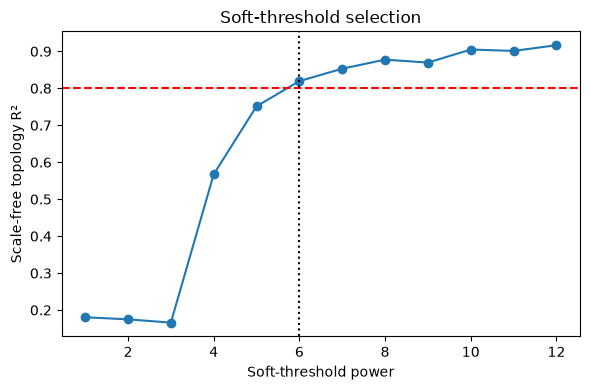


Cut height=0.980 | modules before merge=7 (grey 0.150) -> after merge=7 (grey 0.150)


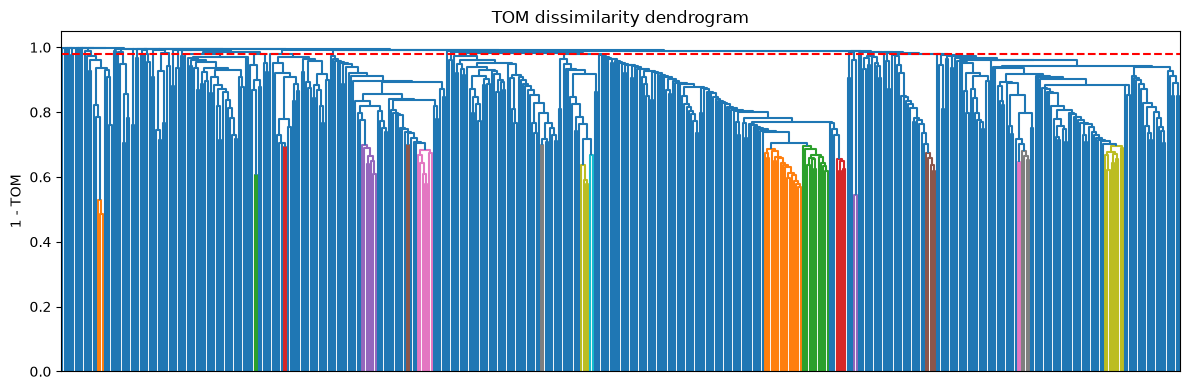


Module-trait results:


,module,n_genes,trait_r,trait_p,trait_FDR,abs_r
0,M01,129,-0.9182,0.0000,0.0000,0.9182
1,M04,47,0.6923,0.0000,0.0000,0.6923
2,M05,29,0.4493,0.0087,0.0203,0.4493
3,M02,129,0.2480,0.1640,0.2871,0.2480
4,M06,27,0.1980,0.2693,0.3771,0.1980
5,M07,12,-0.0938,0.6036,0.7043,0.0938
6,M03,52,0.0032,0.9858,0.9858,0.0032


Tumour-associated modules: ['M01', 'M04', 'M05']
Candidates in those modules      : 60
Set D after |kME| >= 0.5    : 59 (kME filter removed 1 genes)
['A2M', 'ADAMDEC1', 'AL928768.3', 'APOC1', 'AQP8', 'CA1', 'CA4', 'CCL2', 'CCL20', 'CCL3L3', 'CD24', 'CD36', 'CFD', 'CLDN3', 'CLDN4', 'CTSB', 'CTSL', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'DCN', 'EPCAM', 'FBLN1', 'FCER1G', 'GAPDH', 'GDF15', 'GPRC5A', 'GPX2', 'GPX3', 'GSN', 'GUCA2A', 'GUCA2B', 'IGFBP6', 'ITM2C', 'KRT18', 'KRT19', 'KRT8', 'MFAP5', 'MGP', 'MT1E', 'MT1G', 'NQO1', 'OCC1', 'PHGR1', 'PSMB9', 'RGS2', 'S100A11', 'S100A6', 'S100P', 'SELENOP', 'SPARCL1', 'SPINK1', 'SPINK2', 'SPP1', 'TFF3', 'TSPAN8', 'UBE2S', 'ZG16']


In [48]:
# ============================================================
# 4C. Build the network and define Set D
# ============================================================
soft_power, power_table, gene_corr = choose_soft_power(expr, WGCNA_SOFT_POWERS)
power_table.to_csv(OUT_DIR / "WGCNA_soft_threshold.csv", index=False)
print("Chosen soft-threshold power:", soft_power)
display(power_table.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(power_table["power"], power_table["scale_free_R2"], "o-")
ax.axhline(WGCNA_SCALE_FREE_TARGET, ls="--", c="r"); ax.axvline(soft_power, ls=":", c="k")
ax.set_xlabel("Soft-threshold power"); ax.set_ylabel("Scale-free topology R²")
ax.set_title("Soft-threshold selection"); plt.tight_layout()
plt.savefig(OUT_DIR / "WGCNA_soft_threshold.png", dpi=250); plt.show()

adj, tom = adjacency_and_tom(gene_corr, soft_power)
diss = 1.0 - tom; np.fill_diagonal(diss, 0.0)
Z = linkage(squareform(diss, checks=False), method="average")

cut_h, labels0, n_mod0, grey0 = adaptive_tree_cut(
    Z, expr.shape[1], WGCNA_MIN_MODULE_SIZE, max_module_frac=WGCNA_MAX_MODULE_FRAC)
labels = merge_close_modules(expr, labels0, expr.columns.tolist())
n_mod  = len({m for m in labels if m != 0})
grey   = float(np.mean(labels == 0))
print(f"\nCut height={cut_h:.3f} | modules before merge={n_mod0} (grey {grey0:.3f}) "
      f"-> after merge={n_mod} (grey {grey:.3f})")

gene_module = pd.DataFrame({"gene": expr.columns, "module_id": labels})
gene_module["module"] = gene_module["module_id"].map(lambda x: "grey" if x == 0 else f"M{x:02d}")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, no_labels=True, ax=ax); ax.axhline(cut_h, ls="--", c="r")
ax.set_ylabel("1 - TOM"); ax.set_title("TOM dissimilarity dendrogram")
plt.tight_layout(); plt.savefig(OUT_DIR / "WGCNA_dendrogram.png", dpi=250); plt.show()

# ---------- module-trait correlation ----------
trait = sample_meta.loc[expr.index, "Tumor"].astype(float).values
module_eigs, rows = {}, []
for mod in sorted(m for m in gene_module["module"].unique() if m != "grey"):
    gs = gene_module.loc[gene_module["module"] == mod, "gene"].tolist()
    if len(gs) < 2: continue
    eig = module_eigengene(expr, gs); module_eigs[mod] = eig
    r, p = safe_pearson(eig, trait)
    rows.append({"module": mod, "n_genes": len(gs), "trait_r": r, "trait_p": p})

module_trait = pd.DataFrame(rows)
if len(module_trait):
    module_trait["trait_FDR"] = multipletests(module_trait["trait_p"].fillna(1.0).values,
                                              method="fdr_bh")[1]
    module_trait["abs_r"] = module_trait["trait_r"].abs()
    module_trait = module_trait.sort_values(["trait_FDR","abs_r"],
                                            ascending=[True, False]).reset_index(drop=True)

# ---------- kME and gene significance ----------
kme, gs_r = [], []
for _, row in gene_module.iterrows():
    x = expr[row["gene"]].values
    gs_r.append(safe_pearson(x, trait))
    kme.append(safe_pearson(x, module_eigs[row["module"]])
               if row["module"] in module_eigs else (np.nan, np.nan))
gene_module["kME"]        = [a for a, _ in kme]
gene_module["GS_tumor_r"] = [a for a, _ in gs_r]
gene_module["GS_tumor_p"] = [b for _, b in gs_r]

sig_modules = set(module_trait.loc[(module_trait["trait_FDR"] <= WGCNA_TRAIT_FDR) &
                                   (module_trait["abs_r"] >= WGCNA_MIN_ABS_R), "module"])
cand_set = set(candidate_genes_all)
D_module_only = set(gene_module.loc[gene_module["gene"].isin(cand_set) &
                                    gene_module["module"].isin(sig_modules), "gene"])
D_WGCNA = set(gene_module.loc[gene_module["gene"].isin(cand_set) &
                              gene_module["module"].isin(sig_modules) &
                              (gene_module["kME"].abs() >= WGCNA_MIN_ABS_KME), "gene"])

gene_module.to_csv(OUT_DIR / "WGCNA_gene_modules.csv", index=False)
module_trait.to_csv(OUT_DIR / "WGCNA_module_trait.csv", index=False)
(OUT_DIR / "setD_WGCNA_genes.txt").write_text("\n".join(sorted(D_WGCNA)))

print("\nModule-trait results:"); display(module_trait.round(4))
print("Tumour-associated modules:", sorted(sig_modules))
print(f"Candidates in those modules      : {len(D_module_only)}")
print(f"Set D after |kME| >= {WGCNA_MIN_ABS_KME}    : {len(D_WGCNA)} "
      f"(kME filter removed {len(D_module_only) - len(D_WGCNA)} genes)")
print(sorted(D_WGCNA))
if not sig_modules:
    print("WARNING: no module passed the trait criteria; Set D is empty.")

In [49]:
# ============================================================
# 5. A ∩ B ∩ C ∩ D, with the pre-specified A ∩ B fallback
# ============================================================
A, B, C, D = set(A_GO), set(B_KEGG), set(C_STRING), set(D_WGCNA)
primary_ABCD, fallback_AB = A & B & C & D, A & B
selected, mode = ((primary_ABCD, "A∩B∩C∩D") if primary_ABCD else (fallback_AB, "A∩B fallback"))

print("=" * 74)
print(f"A — GO     : {len(A):>3}\nB — KEGG   : {len(B):>3}\n"
      f"C — STRING : {len(C):>3}\nD — WGCNA  : {len(D):>3}")
print("-" * 74)
print(f"A∩B∩C∩D : {len(primary_ABCD)} -> {sorted(primary_ABCD)}")
print(f"A∩B      : {len(fallback_AB)} -> {sorted(fallback_AB)}")
print(f"\nSELECTED ({mode}) = {len(selected)}")
print(sorted(selected)); print("=" * 74)

# ---------- pairwise overlaps ----------
sets = {"A_GO": A, "B_KEGG": B, "C_STRING": C, "D_WGCNA": D}
ov = pd.DataFrame(index=sets, columns=sets, dtype=float)
for i in sets:
    for j in sets:
        ov.loc[i, j] = len(sets[i] & sets[j]) / max(len(sets[i] | sets[j]), 1)
print("\nPairwise Jaccard (A and B share annotation sources — not independent evidence):")
print(ov.astype(float).round(3))

# ---------- membership table ----------
mem = pd.DataFrame({"gene": candidate_genes_all})
mem["external_mappable"] = mem["gene"].isin(candidate_genes_external)
for name, s in sets.items():
    mem[name] = mem["gene"].isin(s)
mem["evidence_count"] = mem[list(sets)].sum(axis=1)
mem["ABCD"]     = mem["gene"].isin(primary_ABCD)
mem["AB"]       = mem["gene"].isin(fallback_AB)
mem["selected"] = mem["gene"].isin(selected)
mem["selection_mode"] = mode
mem = mem.join(ANN, on="gene")

# graded tiers (supplementary; the intersection above remains the primary result)
mem["tier"] = np.where(mem["ABCD"], "Tier1_all_evidence",
              np.where(mem["evidence_count"] >= 2, "Tier2_multi_evidence",
              np.where(mem["evidence_count"] == 1, "Tier3_single_evidence",
                       "Tier4_unannotated_candidate")))
mem = mem.sort_values(["selected","evidence_count","rank"],
                      ascending=[False, False, True]).reset_index(drop=True)
mem.to_csv(OUT_DIR / "evidence_membership.csv", index=False)

print("\nTier distribution:"); print(mem["tier"].value_counts().to_string())
print("\nSelected genes with annotation:")
cols = [c for c in ["gene","evidence_count","rank","direction","lfc_adjusted",
                    "cross_cohort_reproducible","dissociation_associated"] if c in mem.columns]
display(mem[mem["selected"]][cols].round(3))

flagged = sorted(set(selected) & DISSOCIATION_ASSOCIATED)
if flagged:
    print(f"\nNOTE: {flagged} belong to the dissociation-associated chemokine/IEG family. "
          "Report them explicitly and discuss as a limitation.")

A — GO     :  66
B — KEGG   :  42
C — STRING :  11
D — WGCNA  :  59
--------------------------------------------------------------------------
A∩B∩C∩D : 4 -> ['CCL2', 'CXCL8', 'EPCAM', 'GAPDH']
A∩B      : 35 -> ['B2M', 'CCL2', 'CCL20', 'CCL5', 'CD24', 'CD36', 'CLDN3', 'CLDN4', 'CLDN5', 'COL1A1', 'CTSB', 'CTSL', 'CXCL1', 'CXCL13', 'CXCL14', 'CXCL2', 'CXCL3', 'CXCL8', 'CXCR4', 'DUSP2', 'DUSP4', 'DUSP5', 'EPCAM', 'FN1', 'FYN', 'GAPDH', 'GDF15', 'HLA-B', 'HLA-DRA', 'HLA-DRB5', 'KRT18', 'LCN2', 'RAC2', 'S100A11', 'SELENOP']

SELECTED (A∩B∩C∩D) = 4
['CCL2', 'CXCL8', 'EPCAM', 'GAPDH']

Pairwise Jaccard (A and B share annotation sources — not independent evidence):
           A_GO  B_KEGG  C_STRING  D_WGCNA
A_GO      1.000   0.479     0.167    0.374
B_KEGG    0.479   1.000     0.262    0.295
C_STRING  0.167   0.262     1.000    0.061
D_WGCNA   0.374   0.295     0.061    1.000

Tier distribution:
tier
Tier2_multi_evidence           52
Tier3_single_evidence          37
Tier4_unannotated_candidat

,gene,evidence_count,rank,direction,lfc_adjusted,cross_cohort_reproducible,dissociation_associated
0,CXCL8,4,8,UP_in_tumor,0.692,False,True
1,CCL2,4,13,DOWN_in_tumor,-0.307,False,True
2,EPCAM,4,34,UP_in_tumor,0.169,False,False
3,GAPDH,4,49,UP_in_tumor,0.439,False,False



NOTE: ['CCL2', 'CXCL8'] belong to the dissociation-associated chemokine/IEG family. Report them explicitly and discuss as a limitation.


In [50]:
# ============================================================
# 6. Sensitivity: does the intersection depend on the term cap?
# ============================================================
sens = []
for cap in TERM_CAP_GRID:
    a = genes_from_terms(cap_terms(go_sig,   cap, True))
    b = genes_from_terms(cap_terms(kegg_sig, cap, False))
    abcd = a & b & C & D
    sens.append({"term_cap": "all" if cap is None else cap,
                 "A": len(a), "B": len(b), "A∩B": len(a & b),
                 "A∩B∩C∩D": len(abcd), "genes": ";".join(sorted(abcd))})
sens = pd.DataFrame(sens)
sens.to_csv(OUT_DIR / "term_cap_sensitivity.csv", index=False)
print("Term-cap sensitivity (Set C and D fixed):")
display(sens)

stable = set.intersection(*[set(r.split(";")) for r in sens["genes"] if r]) if sens["genes"].any() else set()
print("Genes selected at EVERY cap (most robust):", sorted(stable) or "none")

Term-cap sensitivity (Set C and D fixed):


,term_cap,A,B,A∩B,A∩B∩C∩D,genes
0,10,39,22,18,2,CCL2;CXCL8
1,25,66,42,35,4,CCL2;CXCL8;EPCAM;GAPDH
2,all,72,42,35,4,CCL2;CXCL8;EPCAM;GAPDH


Genes selected at EVERY cap (most robust): ['CCL2', 'CXCL8']


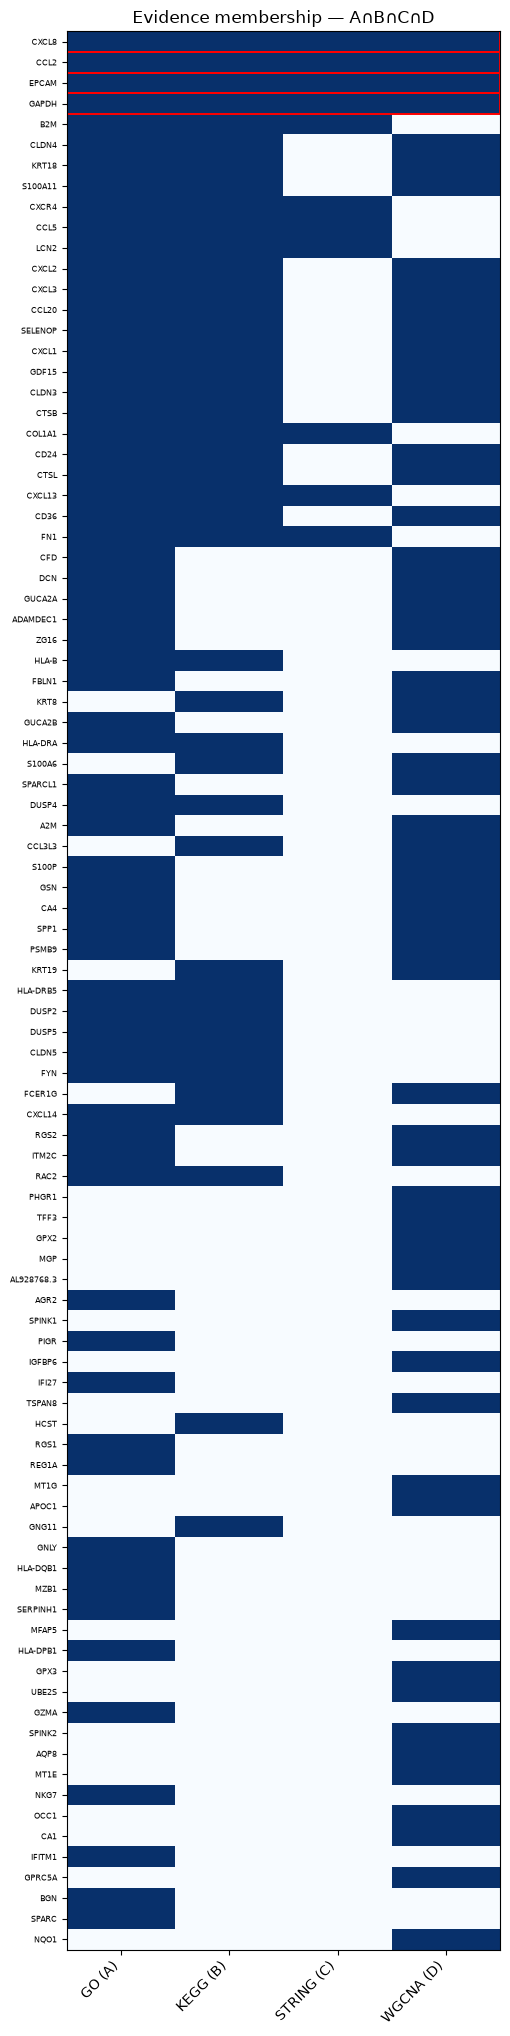

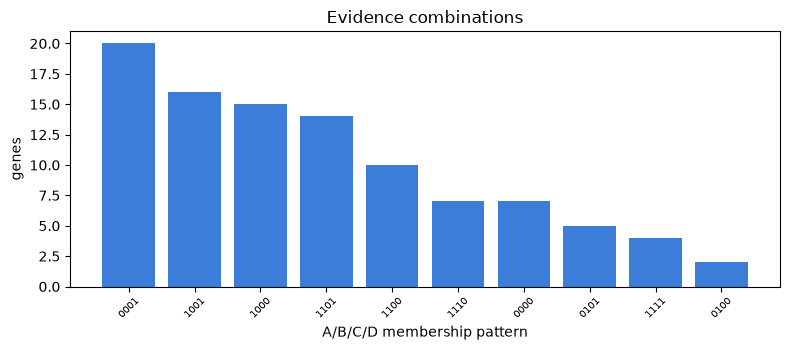

In [51]:
# ============================================================
# 7. Evidence membership figure
# ============================================================
show = mem[mem["evidence_count"] >= 1].copy().sort_values(
    ["evidence_count","rank"], ascending=[False, True])
if len(show):
    M = show[list(sets)].astype(int).values
    fig, ax = plt.subplots(figsize=(5.2, max(4, 0.22 * len(show))))
    ax.imshow(M, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(sets)))
    ax.set_xticklabels(["GO (A)","KEGG (B)","STRING (C)","WGCNA (D)"], rotation=45, ha="right")
    ax.set_yticks(range(len(show)))
    ax.set_yticklabels(show["gene"], fontsize=6)
    for i, g in enumerate(show["gene"]):
        if g in selected:
            ax.add_patch(plt.Rectangle((-0.5, i - 0.5), len(sets), 1,
                                       fill=False, edgecolor="red", lw=1.4))
    ax.set_title(f"Evidence membership — {mode}")
    plt.tight_layout(); plt.savefig(OUT_DIR / "evidence_membership.png", dpi=300,
                                    bbox_inches="tight"); plt.show()

combo = (mem[list(sets)].astype(int).astype(str).agg("".join, axis=1)
         .value_counts().sort_values(ascending=False).head(12))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(range(len(combo)), combo.values, color="#3b7dd8")
ax.set_xticks(range(len(combo))); ax.set_xticklabels(combo.index, rotation=45, fontsize=7)
ax.set_ylabel("genes"); ax.set_xlabel("A/B/C/D membership pattern")
ax.set_title("Evidence combinations")
plt.tight_layout(); plt.savefig(OUT_DIR / "evidence_combinations.png", dpi=300); plt.show()

In [52]:
# ============================================================
# 8. Export final package + Notebook 09 handoff
# ============================================================
final_tbl = mem[mem["selected"]].copy()
final_tbl.to_csv(OUT_DIR / "FINAL_selected_genes.csv", index=False)
(OUT_DIR / "FINAL_selected_genes.txt").write_text("\n".join(sorted(selected)))
(OUT_DIR / "TIER1_TIER2_genes.txt").write_text(
    "\n".join(sorted(mem.loc[mem["evidence_count"] >= 2, "gene"])))

SUMMARY = {
    "candidates_total": len(candidate_genes_all),
    "candidates_external_mappable": len(candidate_genes_external),
    "unmappable": external_unmappable,
    "background_size": len(background_external),
    "GO_libraries": resolved_go, "KEGG_library": kegg_libname,
    "GO_terms_significant": int(len(go_sig)), "KEGG_terms_significant": int(len(kegg_sig)),
    "setA_GO": len(A), "setB_KEGG": len(B), "setC_STRING": len(C), "setD_WGCNA": len(D),
    "string_network_type": STRING_NETWORK_TYPE,
    "string_physical_setC": sorted(C_phys),
    "wgcna_soft_power": int(soft_power), "wgcna_modules": int(n_mod),
    "wgcna_grey_fraction": round(grey, 3),
    "wgcna_significant_modules": sorted(sig_modules),
    "ABCD": sorted(primary_ABCD), "AB": sorted(fallback_AB),
    "selection_mode": mode, "selected": sorted(selected),
    "selected_dissociation_flagged": sorted(set(selected) & DISSOCIATION_ASSOCIATED),
    "stable_across_term_caps": sorted(stable),
}
(OUT_DIR / "SUMMARY.json").write_text(json.dumps(SUMMARY, indent=2, default=str))
print(json.dumps(SUMMARY, indent=2, default=str))

print("\n--- Notebook 09 (TCGA COADREAD survival) inputs ---")
print("Primary  :", OUT_DIR / "FINAL_selected_genes.txt")
print("Broader  :", OUT_DIR / "TIER1_TIER2_genes.txt")
print("Full table:", OUT_DIR / "evidence_membership.csv")
print("\nMethods must state: hypergeometric ORA against the 2,935-gene shared feature space "
      "(not the whole genome); Benjamini-Hochberg FDR applied jointly across GO sub-ontologies; "
      "STRING confidence >=0.4 with cytoHubba-style top-20 metrics and documented tie-breaking; "
      "correlation network implemented in Python following the WGCNA framework "
      "(soft-thresholding, TOM, adaptive tree cut, eigengene merging) — not the WGCNA R package.")

{
  "candidates_total": 100,
  "candidates_external_mappable": 99,
  "unmappable": [
    "AL928768.3"
  ],
  "background_size": 2632,
  "GO_libraries": [
    "GO_Biological_Process_2026",
    "GO_Molecular_Function_2026",
    "GO_Cellular_Component_2026"
  ],
  "KEGG_library": "KEGG_2026",
  "GO_terms_significant": 76,
  "KEGG_terms_significant": 28,
  "setA_GO": 66,
  "setB_KEGG": 42,
  "setC_STRING": 11,
  "setD_WGCNA": 59,
  "string_network_type": "functional",
  "string_physical_setC": [
    "COL1A1",
    "CXCL8",
    "CXCR4",
    "FN1",
    "SPP1"
  ],
  "wgcna_soft_power": 6,
  "wgcna_modules": 7,
  "wgcna_grey_fraction": 0.15,
  "wgcna_significant_modules": [
    "M01",
    "M04",
    "M05"
  ],
  "ABCD": [
    "CCL2",
    "CXCL8",
    "EPCAM",
    "GAPDH"
  ],
  "AB": [
    "B2M",
    "CCL2",
    "CCL20",
    "CCL5",
    "CD24",
    "CD36",
    "CLDN3",
    "CLDN4",
    "CLDN5",
    "COL1A1",
    "CTSB",
    "CTSL",
    "CXCL1",
    "CXCL13",
    "CXCL14",
    "CXCL2",
    "CXC